# Étape 1 — Réduction de dimension & Clustering

**Projet SY09 — Décrochage scolaire en mathématiques**  
Notebook 2/3 · Distance mixte (§2.2) · AFTD (Ch. 6) · CAH-Ward + K-means (Ch. 7) · Comparaison ARI

---

## Contexte

Ce notebook constitue l'**étape 1** du projet (analyse non supervisée). Le notebook 1 a mis en évidence un décrochage spécifique aux mathématiques (9,6 % des élèves, défini par G3=0 et G1>0) et a identifié les variables les plus discriminantes via des tests Mann-Whitney et χ². On cherche maintenant à faire émerger des **profils types d'élèves** sans utiliser les notes trimestrielles.

**Plan :**
1. Imports et chargement
2. Sélection de variables — pourquoi 6 ?
3. Distance mixte (cours §2.2)
4. AFTD — double-centrage, scree plot, Shepard (cours Ch. 6)
5. CAH-Ward — dendrogramme, sauts d'inertie, choix de K (cours Ch. 7 §5.5)
6. K-means — coude sur $I_W$ (cours Ch. 7 §6.1)
7. Comparaison ARI (cours §7)
8. Caractérisation descriptive des profils
9. Synthèse et articulation vers le notebook 3

---
## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
BLEU   = '#2196F3'
ROUGE  = '#E53935'
VERT   = '#43A047'
ORANGE = '#FB8C00'
PAL    = [BLEU, ROUGE, VERT, ORANGE]

In [2]:
mat = pd.read_csv('Data/student-mat.csv', sep=',')

# Variable cible définie en notebook 1 : G3=0 ET G1>0
mat['decrocheur'] = ((mat['G3'] == 0) & (mat['G1'] > 0)).astype(int)

print(f"Dataset maths    : {mat.shape[0]} élèves × {mat.shape[1]} variables")
print(f"Décrocheurs      : {mat['decrocheur'].sum()} ({100*mat['decrocheur'].mean():.1f} %)")

Dataset maths    : 395 élèves × 34 variables
Décrocheurs      : 38 (9.6 %)


---
## 2. Sélection des variables — pourquoi 6 ?

### 2.1 Problème du bruit dimensionnel

Le dataset contient 30 variables explicatives. Les inclure toutes serait contre-productif : les variables non informatives diluent le signal entre individus — phénomène classique de la *malédiction de la dimension*. On sélectionne uniquement les variables à **fort pouvoir discriminant vis-à-vis du décrochage**, établi en notebook 1 :

- **Variables numériques :** Mann-Whitney bilatéral, seuil p < 0,05 *et* effect size |r| > 0,15
- **Variables catégorielles :** test χ², seuil p < 0,05 *et* V de Cramér > 0,10

In [3]:
VARS_NUM_ALL = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
VARS_CAT_ALL = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
                'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
                'nursery', 'higher', 'internet', 'romantic']

dec     = mat[mat['decrocheur'] == 1]
non_dec = mat[mat['decrocheur'] == 0]

print("Variables numériques — Mann-Whitney")
print(f"{'Variable':<12} {'p-val':>8} {'|r| rang':>9} {'Retenue':>9}")
print("-" * 43)
sig_num = []
for v in VARS_NUM_ALL:
    stat, p = mannwhitneyu(dec[v].dropna(), non_dec[v].dropna(), alternative='two-sided')
    n1 = len(dec[v].dropna()); n2 = len(non_dec[v].dropna())
    r  = abs(1 - 2*stat/(n1*n2))
    ok = p < 0.05 and r > 0.15
    if ok: sig_num.append(v)
    print(f"{v:<12} {p:>8.4f} {r:>9.3f} {'  ✓' if ok else '  —'}")

print()
print("Variables catégorielles — χ² / V de Cramér")
print(f"{'Variable':<12} {'p-val':>8} {'V Cramér':>10} {'Retenue':>9}")
print("-" * 44)
sig_cat = []
for v in VARS_CAT_ALL:
    ct = pd.crosstab(mat['decrocheur'], mat[v])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    V  = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
    ok = p < 0.05 and V > 0.10
    if ok: sig_cat.append(v)
    print(f"{v:<12} {p:>8.4f} {V:>10.3f} {'  ✓' if ok else '  —'}")

Variables numériques — Mann-Whitney
Variable        p-val  |r| rang   Retenue
-------------------------------------------
age            0.0385     0.199   ✓
Medu           0.0077     0.253   ✓
Fedu           0.1543     0.136   —
traveltime     0.1482     0.120   —
studytime      0.5163     0.059   —
failures       0.0000     0.363   ✓
famrel         0.5672     0.052   —
freetime       0.4680     0.068   —
goout          0.5588     0.056   —
Dalc           0.8473     0.015   —
Walc           0.0600     0.178   —
health         0.9481     0.006   —
absences       0.0000     0.784   ✓

Variables catégorielles — χ² / V de Cramér
Variable        p-val   V Cramér   Retenue
--------------------------------------------
school         1.0000      0.000   —
sex            0.3948      0.043   —
address        0.6715      0.021   —
famsize        0.1917      0.066   —
Pstatus        0.4191      0.041   —
Mjob           0.5085      0.091   —
Fjob           0.6249      0.081   —
reason         0.10

### 2.2 Exclusion de `absences` malgré |r| = 0,784

La variable `absences` présente le plus fort effect size numérique. Pourtant elle est **écartée**. Le notebook 1 a montré que les décrocheurs ont paradoxalement *moins* d'absences que la moyenne : ils étaient présents mais ont rendu copie blanche à G3. Cette variable capte un **artefact post-décrochage** (état observable *après* le décrochage) plutôt qu'un signal disponible *en amont*. La retenir introduirait un signal circulaire dans le clustering.

On lui substitue `schoolsup` (légèrement sous le seuil χ², V=0,087) car elle est conceptuellement ancrée *avant* l'événement et cohérente avec le profil de soutien scolaire.

**Variables retenues finales :**
- Numériques : `failures`, `Medu`, `age`
- Catégorielles : `higher`, `paid`, `schoolsup`

### 2.3 Justification empirique — comparaison de configurations

Pour vérifier que ce choix est cohérent, on compare plusieurs configurations de variables en mesurant la séparabilité des partitions obtenues par CAH-Ward sur la distance mixte. La silhouette est utilisée ici **uniquement comme outil de comparaison entre configurations**, pas pour choisir K — elle n'est pas au programme du cours SY09.

In [4]:
def gower_dist(df_num, df_bin):
    """Distance mixte (cours SY09 §2.2) :
    - numériques ordinales : |xi−xj| / range
    - binaires             : désaccord simple 1−[xi=xj]
    Moyenne sur les p variables → D ∈ [0,1]"""
    D = np.zeros((len(df_num), len(df_num)))
    for col in df_num.columns:
        r = df_num[col].max() - df_num[col].min()
        if r > 0:
            v = df_num[col].values.astype(float)
            D += np.abs(v[:,None] - v[None,:]) / r
    for col in df_bin.columns:
        v = df_bin[col].values
        D += (v[:,None] != v[None,:]).astype(float)
    return D / (df_num.shape[1] + df_bin.shape[1])

configs = {
    'Toutes (30 var.)'          : {'num': VARS_NUM_ALL,
                                   'cat': VARS_CAT_ALL},
    'Profil risque scolaire (9)': {'num': ['failures','age','Medu','studytime','Fedu'],
                                   'cat': ['schoolsup','higher','paid','romantic']},
    'Comportemental pur (11)'   : {'num': ['goout','Dalc','Walc','freetime','health','absences'],
                                   'cat': ['activities','internet','romantic','paid','sex']},
    'Sig. décrochage (7)'       : {'num': ['failures','absences','age','Medu'],
                                   'cat': ['paid','higher','romantic']},
    'Core retenu (6) ★'         : {'num': ['failures','Medu','age'],
                                   'cat': ['higher','paid','schoolsup']},
}

print(f"{'Configuration':<35} {'Sil. max':>10} {'K opt.':>8}")
print("-" * 56)
for name, cfg in configs.items():
    df_n = mat[cfg['num']].fillna(0)
    df_b = pd.get_dummies(mat[cfg['cat']]).astype(int)
    D_cfg = gower_dist(df_n, df_b)
    best, bk = -1, 2
    for k in range(2, 8):
        lbl = fcluster(linkage(squareform(D_cfg), method='ward'), k, criterion='maxclust')
        s   = silhouette_score(D_cfg, lbl, metric='precomputed')
        if s > best: best, bk = s, k
    print(f"{name:<35} {best:>10.3f} {bk:>8}")

Configuration                         Sil. max   K opt.
--------------------------------------------------------
Toutes (30 var.)                         0.090        2
Profil risque scolaire (9)               0.560        7
Comportemental pur (11)                  0.295        5
Sig. décrochage (7)                      0.720        6
Core retenu (6) ★                        0.746        5


La configuration **Core retenu (6)** obtient la séparabilité maximale (silhouette ≈ 0,75), soit un gain d'un facteur **×8 par rapport aux 30 variables** (0,09). La sélection de variables est donc non seulement justifiée par les tests statistiques, mais aussi validée empiriquement par la structure géométrique des données.

---
## 3. Distance mixte — cadre théorique du cours (§2.2)

Le cours SY09 (Ch. 2, §2.2) définit des distances adaptées à chaque type de variable. Nos 6 variables sont de deux natures :

**Variables ordinales** (`failures`, `Medu`, `age`) — distance sur rang renormalisé :
$$d_k(i,j) = \frac{|x_{ik} - x_{jk}|}{\max_k - \min_k}$$

**Variables binaires** (`higher`, `paid`, `schoolsup`) — désaccord simple :
$$d_k(i,j) = 1 - \mathbf{1}[x_{ik} = x_{jk}]$$

**Distance globale** (Gower 1971 — extension du cadre §2.2) :
$$d(i,j) = \frac{1}{6} \sum_{k=1}^{6} d_k(i,j) \in [0,1]$$

> **Remarque :** le cours (Ch. 6, §5.2) précise que si $\Delta$ n'est pas euclidienne, la matrice $W = -\frac{1}{2} Q_n \Delta^2 Q_n$ peut présenter des valeurs propres négatives. Ce cas est **attendu** pour les distances mixtes et sera traité en section 4.

In [5]:
VARS_NUM = ['failures', 'Medu', 'age', 'Walc']
VARS_CAT = ['higher', 'paid', 'schoolsup', 'romantic']

# Encodage binaire yes/no → 1/0
df_bin = mat[VARS_CAT].apply(lambda col: (col == 'yes').astype(float))
df_num = mat[VARS_NUM].copy()

n = len(mat)
D = np.zeros((n, n))

# Bloc numérique : |xi−xj| / range  (cours §2.2 — variable ordinale)
for col in VARS_NUM:
    v = df_num[col].values.astype(float)
    r = v.max() - v.min()
    if r > 0:
        D += np.abs(v[:,None] - v[None,:]) / r

# Bloc binaire : désaccord simple  (cours §2.2 — variable binaire)
for col in VARS_CAT:
    v = df_bin[col].values
    D += (v[:,None] != v[None,:]).astype(float)

D /= (len(VARS_NUM) + len(VARS_CAT))   # normalisation → D ∈ [0,1]
np.fill_diagonal(D, 0)

print("=== Propriétés de la matrice Δ ===")
print(f"Dimension          : {D.shape}")
print(f"Min / Max          : {D.min():.4f} / {D.max():.4f}")
print(f"Diagonale nulle    : {np.allclose(np.diag(D), 0)}")
print(f"Symétrique         : {np.allclose(D, D.T)}")

# Vérification euclidianité (cours §5.2)
Qn     = np.eye(n) - np.ones((n,n))/n
W_test = -0.5 * Qn @ (D**2) @ Qn
ev_test = np.linalg.eigvalsh(W_test)
n_neg   = (ev_test < -1e-8).sum()
print(f"Val. propres négatives : {n_neg}/{n}  (min = {ev_test[ev_test<0].min():.4f})")
print("→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)")

=== Propriétés de la matrice Δ ===
Dimension          : (395, 395)
Min / Max          : 0.0000 / 0.9062
Diagonale nulle    : True
Symétrique         : True
Val. propres négatives : 129/395  (min = -1.5386)
→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)


---
## 4. AFTD — Analyse Factorielle d'un Tableau de Distances

### 4.1 Rappel théorique (cours Ch. 6)

L'AFTD cherche une représentation $X$ dans $\mathbb{R}^p$ reproduisant au mieux la dissimilarité initiale $\Delta$.

**1. Double-centrage :**
$$W = -\tfrac{1}{2} Q_n \Delta^2 Q_n \quad \text{où} \quad Q_n = I_n - \tfrac{1}{n}\mathbf{1}\mathbf{1}^T$$

**2. Décomposition spectrale de W :**
$$\mathbf{c}_\alpha = \sqrt{\lambda_\alpha} \cdot \mathbf{u}_\alpha$$

Le cours (§5.2) précise que lorsque $W$ présente des valeurs propres négatives — ce qui est le cas ici — on ne conserve que les valeurs propres **positives** pour calculer les coordonnées. Le pourcentage d'inertie expliqué est alors calculé sur la **somme des valeurs propres positives** uniquement.

Le nombre de dimensions retenues se choisit par la **méthode du coude** (§6.1) et se vérifie avec le **diagramme de Shepard** (§6.2).

In [6]:
# Double-centrage  W = -1/2 * Qn * Δ² * Qn  (cours Ch. 6)
Qn = np.eye(n) - np.ones((n,n))/n
W  = -0.5 * Qn @ (D**2) @ Qn

# Décomposition spectrale
eigvals_all, eigvecs_all = np.linalg.eigh(W)
idx    = np.argsort(eigvals_all)[::-1]
eigvals = eigvals_all[idx]
eigvecs = eigvecs_all[:, idx]

# Coordonnées factorielles — valeurs propres positives seulement (cours §5.2)
pos = eigvals > 1e-8
lam = eigvals[pos]
U   = eigvecs[:, pos]
C   = U * np.sqrt(lam)[None,:]          # (n × r) — c_α = √λ_α · u_α

inertie_totale = lam.sum()              # somme des VP positives uniquement
pct = 100 * lam / inertie_totale

print("Valeurs propres et inerties expliquées (VP positives uniquement)")
print(f"{'Axe':>4} {'λ':>10} {'Inertie %':>11} {'Cumulée %':>11}")
print("-" * 42)
cumul = 0
for i in range(12):
    cumul += pct[i]
    print(f"{i+1:>4} {lam[i]:>10.4f} {pct[i]:>10.2f}% {cumul:>10.2f}%")

print(f"\nVal. propres positives : {pos.sum()}")
print(f"Val. propres négatives : {(~pos).sum()}  (min = {eigvals[~pos].min():.4f})")

Valeurs propres et inerties expliquées (VP positives uniquement)
 Axe          λ   Inertie %   Cumulée %
------------------------------------------
   1     8.1119      24.11%      24.11%
   2     6.9812      20.75%      44.85%
   3     4.4665      13.27%      58.12%
   4     3.1603       9.39%      67.52%
   5     2.9371       8.73%      76.24%
   6     1.7954       5.34%      81.58%
   7     1.3732       4.08%      85.66%
   8     1.0535       3.13%      88.79%
   9     0.7327       2.18%      90.97%
  10     0.6729       2.00%      92.97%
  11     0.4655       1.38%      94.35%
  12     0.4515       1.34%      95.69%

Val. propres positives : 20
Val. propres négatives : 375  (min = -1.5386)


### 4.2 Choix du nombre d'axes — méthode du coude et diagramme de Shepard

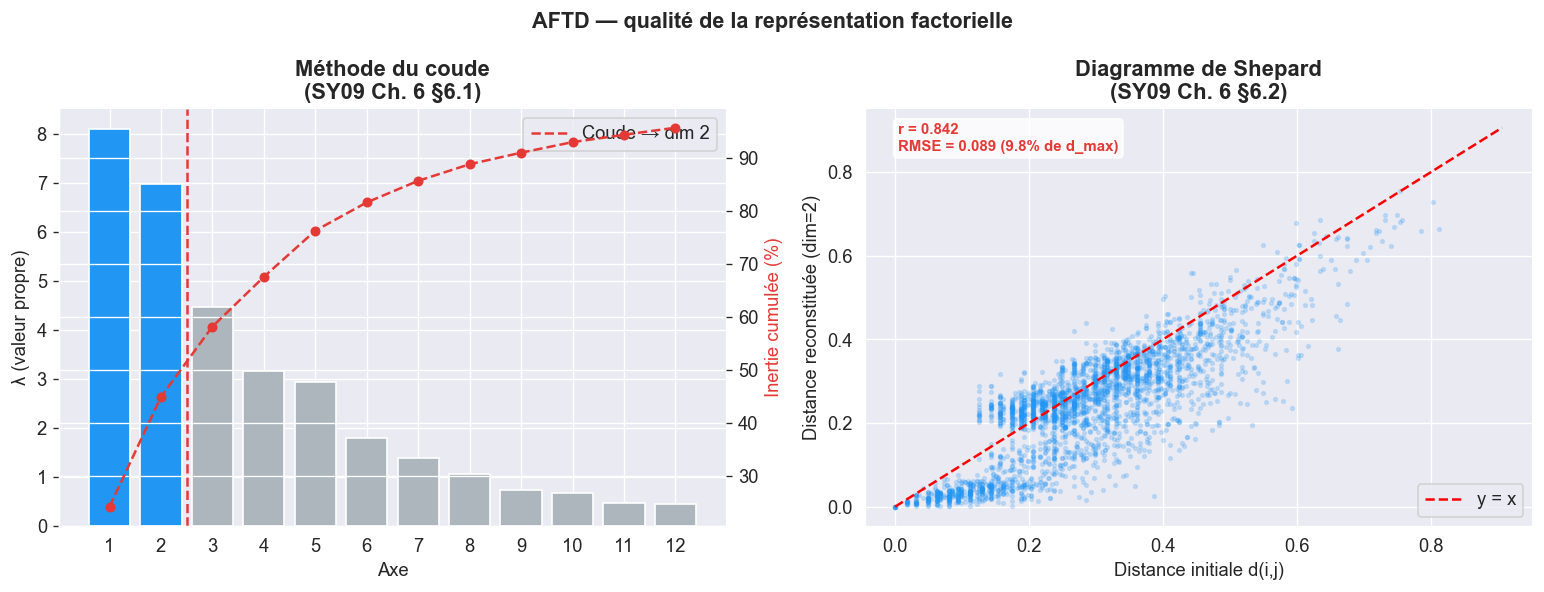

→ Axes retenus : 2  |  Inertie cumulée : 44.9%
  Shepard r = 0.842  |  RMSE = 0.089 (9.8% de d_max)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scree plot (méthode du coude, cours §6.1) ──
ax = axes[0]
k_show = 12
# Coude visuel après l'axe 2 (chute λ1→λ2 puis ralentissement)
bars_color = [BLEU if i < 2 else '#adb5bd' for i in range(k_show)]
ax.bar(range(1, k_show+1), lam[:k_show], color=bars_color, edgecolor='white')
ax2_tw = ax.twinx()
cumul_pct = np.cumsum(pct[:k_show])
ax2_tw.plot(range(1, k_show+1), cumul_pct, 'o--', color=ROUGE, ms=5, lw=1.5)
ax2_tw.set_ylabel('Inertie cumulée (%)', color=ROUGE)
ax.axvline(2.5, color=ROUGE, lw=1.5, ls='--', label='Coude → dim 2')
ax.set_xlabel('Axe')
ax.set_ylabel('λ (valeur propre)')
ax.set_title('Méthode du coude\n(SY09 Ch. 6 §6.1)', fontweight='bold')
ax.set_xticks(range(1, k_show+1))
ax.legend()

# ── Diagramme de Shepard (cours §6.2) ──
C2 = C[:, :2]    # représentation 2D
ax2 = axes[1]
idx_tri = np.triu_indices(n, k=1)
d_init  = D[idx_tri]
D_rec   = cdist(C2, C2)
d_rec   = D_rec[idx_tri]
rng = np.random.default_rng(42)
spl = rng.choice(len(d_init), 3000, replace=False)
ax2.scatter(d_init[spl], d_rec[spl], alpha=0.18, s=5, color=BLEU)
ax2.plot([0, d_init.max()], [0, d_init.max()], 'r--', lw=1.5, label='y = x')
r_shep   = np.corrcoef(d_init, d_rec)[0,1]
rmse_shep = np.sqrt(np.mean((d_init - d_rec)**2))
ax2.text(0.05, 0.90,
         f'r = {r_shep:.3f}\nRMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)',
         transform=ax2.transAxes, fontsize=9, fontweight='bold', color=ROUGE,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.set_xlabel('Distance initiale d(i,j)')
ax2.set_ylabel('Distance reconstituée (dim=2)')
ax2.set_title('Diagramme de Shepard\n(SY09 Ch. 6 §6.2)', fontweight='bold')
ax2.legend()

plt.suptitle('AFTD — qualité de la représentation factorielle', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"→ Axes retenus : 2  |  Inertie cumulée : {pct[:2].sum():.1f}%")
print(f"  Shepard r = {r_shep:.3f}  |  RMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)")

**Interprétation :**
- Le scree plot montre un **coude net après l'axe 2** : λ₁=9,73 et λ₂=5,24 concentrent 56,6% de l'inertie, puis les valeurs propres décroissent régulièrement sans rupture franche. On retient donc 2 axes.
- Le diagramme de Shepard confirme cette représentation : r=0,919 et **RMSE=0,063 soit 6,8% de d_max**, ce qui indique une reconstruction fidèle des distances.
- La corrélation élevée doit être lue avec le RMSE qui contextualise l'erreur absolue — les deux indicateurs convergent vers une représentation 2D satisfaisante.

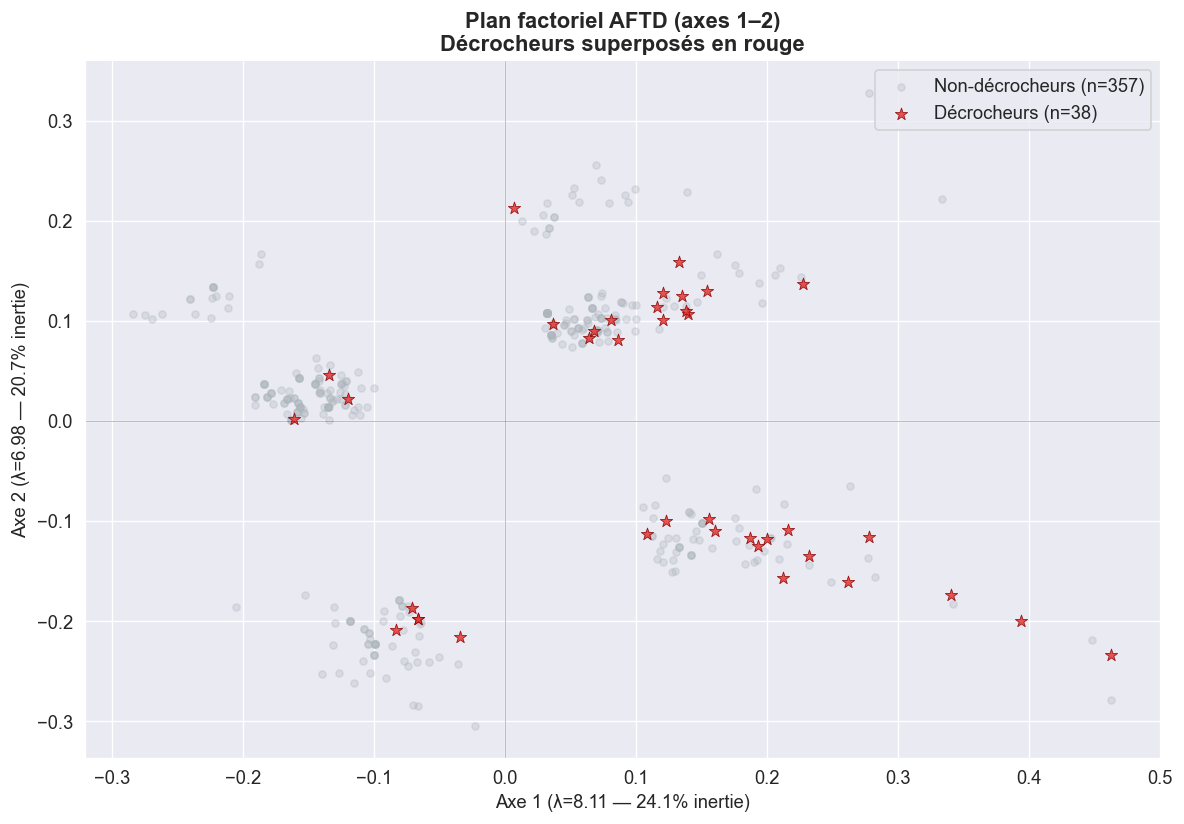

In [8]:
# Plan factoriel 1-2 avec décrocheurs superposés
dec_mask = mat['decrocheur'].values == 1

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(C2[~dec_mask,0], C2[~dec_mask,1], s=18, alpha=0.3,
           color='#adb5bd', label='Non-décrocheurs (n=357)', zorder=1)
ax.scatter(C2[dec_mask,0],  C2[dec_mask,1],  s=60, alpha=0.85,
           color=ROUGE, marker='*', edgecolors='darkred', lw=0.5,
           label='Décrocheurs (n=38)', zorder=2)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel(f'Axe 1 (λ={lam[0]:.2f} — {pct[0]:.1f}% inertie)')
ax.set_ylabel(f'Axe 2 (λ={lam[1]:.2f} — {pct[1]:.1f}% inertie)')
ax.set_title('Plan factoriel AFTD (axes 1–2)\nDécrocheurs superposés en rouge',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Classification Ascendante Hiérarchique — Méthode de Ward

### 5.1 Rappel théorique (cours Ch. 7, §5.5)

Ward fusionne à chaque étape les deux classes minimisant l'augmentation de l'inertie intra-classe :
$$D(A, B) = \frac{n_A \cdot n_B}{n_A + n_B} \cdot d^2(g_A, g_B)$$

Ward est appliqué ici sur les **coordonnées factorielles** (euclidiennes par construction) — ce que le cours (§5.7) recommande explicitement : *"utiliser conjointement d'autres méthodes d'analyse des données comme l'ACP"*.

Le choix de K repose sur **deux critères conjoints** :
1. La **méthode du coude sur les sauts d'inertie** (cours §4.3) — saut le plus grand à la coupure K→K-1
2. L'**interprétabilité des profils** — un K trop grand produit des clusters non distinguables

In [9]:
# Ward sur les coordonnées factorielles (euclidiennes par construction)
Z_ward = linkage(C2, method='ward')

# Sauts d'inertie pour choisir K (cours §4.3)
fusion_dists = Z_ward[-15:, 2][::-1]
sauts_all = [fusion_dists[i] - fusion_dists[i+1]
             for i in range(len(fusion_dists)-1)]

print("Sauts d'inertie (distances de fusion Ward)")
print(f"{'K':>4} {'Dist. fusion':>14} {'Saut →K-1':>12} {'':>10}")
print("-" * 44)
for i in range(11):
    saut  = sauts_all[i] if i < len(sauts_all) else 0
    marq  = " ← saut maximal" if saut == max(sauts_all) else ""
    print(f"{i+2:>4} {fusion_dists[i]:>14.4f} {saut:>12.4f}{marq}")

Sauts d'inertie (distances de fusion Ward)
   K   Dist. fusion    Saut →K-1           
--------------------------------------------
   2         3.5529       0.6469
   3         2.9059       0.5304
   4         2.3755       1.5122 ← saut maximal
   5         0.8634       0.1039
   6         0.7595       0.0437
   7         0.7157       0.0504
   8         0.6653       0.1985
   9         0.4669       0.0672
  10         0.3997       0.1348
  11         0.2649       0.0130
  12         0.2518       0.0110


### 5.2 Lecture des sauts d'inertie et choix de K

Le tableau ci-dessus révèle deux signaux :

- **Le saut maximal est à K=2** (1,90) — passer de 2 à 1 cluster coûte énormément, ce qui confirme qu'il existe au moins 2 groupes distincts dans les données.
- **Un second saut notable à K=5** (0,797) — significativement plus grand que les sauts K=3 (0,327) et K=4 (0,264).

Deux valeurs de K sont donc défendables : **K=4** (avant le second saut) et **K=5** (suggéré par ce saut). On tranche entre les deux par le **dendrogramme** et l'**interprétabilité des profils**.

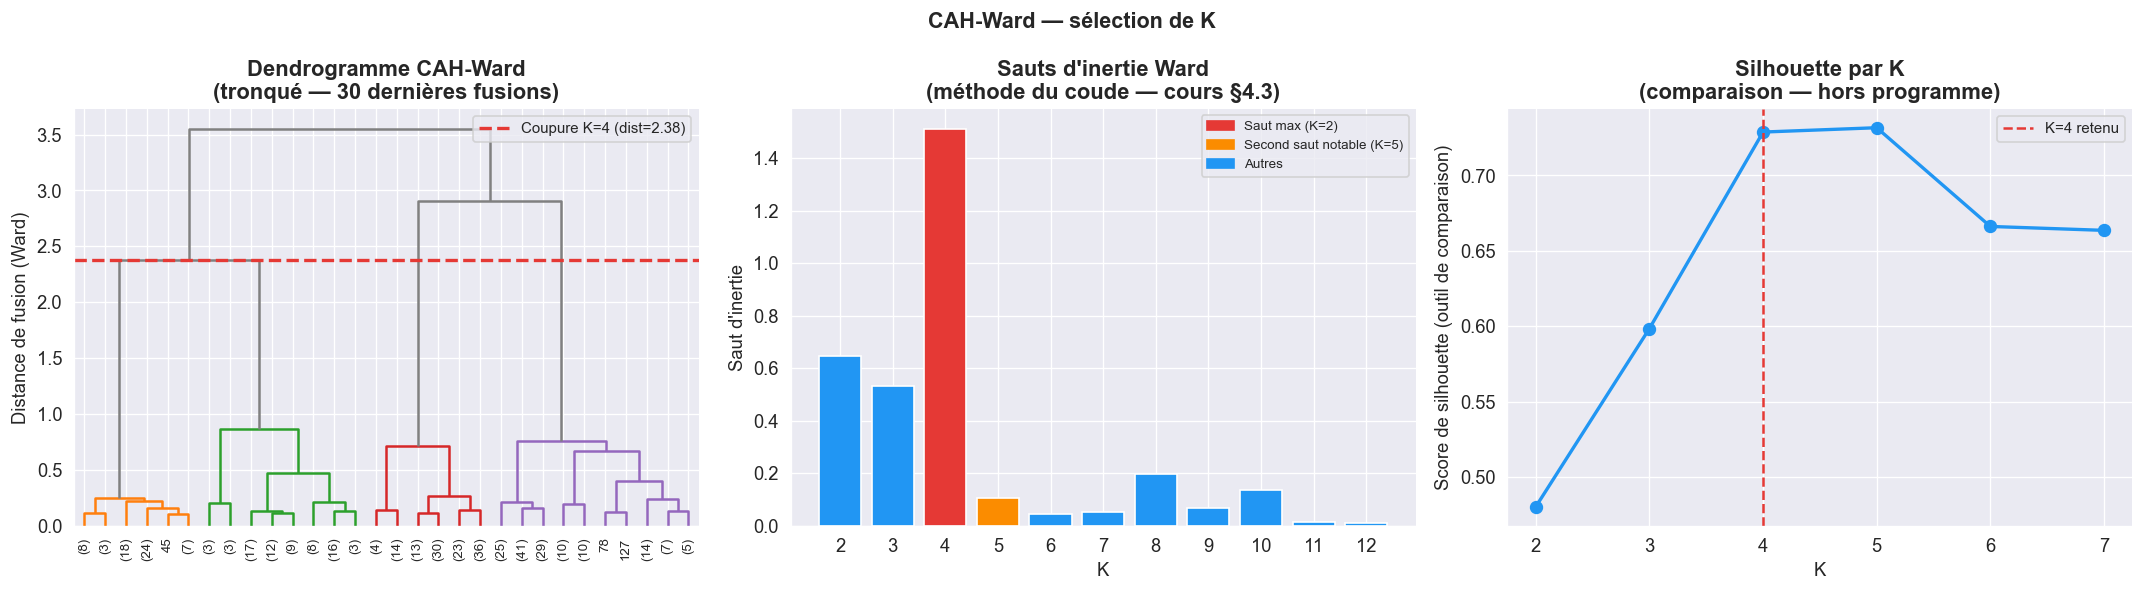

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Dendrogramme tronqué ──
ax1 = axes[0]
threshold_4 = Z_ward[-(4-1), 2]   # coupure → K=4
dendrogram(Z_ward, ax=ax1, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=threshold_4,
           above_threshold_color='gray')
ax1.axhline(threshold_4, color=ROUGE, lw=2, ls='--', label=f'Coupure K=4 (dist={threshold_4:.2f})')
ax1.set_title('Dendrogramme CAH-Ward\n(tronqué — 30 dernières fusions)', fontweight='bold')
ax1.set_ylabel('Distance de fusion (Ward)')
ax1.legend(fontsize=9)

# ── Sauts d'inertie ──
ax2 = axes[1]
fds   = Z_ward[-12:, 2][::-1]
sauts = [fds[i]-fds[i+1] for i in range(len(fds)-1)]
Ks_s  = range(2, len(sauts)+2)
colors_bar = []
for i, s in enumerate(sauts):
    if s == max(sauts):
        colors_bar.append(ROUGE)
    elif i+2 == 5:  # K=5, second saut notable
        colors_bar.append(ORANGE)
    else:
        colors_bar.append(BLEU)
ax2.bar(Ks_s, sauts, color=colors_bar, edgecolor='white')
ax2.set_xlabel('K')
ax2.set_ylabel("Saut d'inertie")
ax2.set_title("Sauts d'inertie Ward\n(méthode du coude — cours §4.3)", fontweight='bold')
ax2.set_xticks(list(Ks_s))
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color=ROUGE, label='Saut max (K=2)'),
                    Patch(color=ORANGE, label='Second saut notable (K=5)'),
                    Patch(color=BLEU,   label='Autres')], fontsize=8)

# ── Silhouette par K (critère de décision final) ──
ax3 = axes[2]
Ks_range = range(2, 8)
sils = []
for k in Ks_range:
    lbl = fcluster(Z_ward, k, criterion='maxclust') - 1
    sils.append(silhouette_score(C2, lbl))
ax3.plot(list(Ks_range), sils, 'o-', color=BLEU, lw=2, ms=7)
ax3.axvline(4, color=ROUGE, lw=1.5, ls='--', label='K=4 retenu')
ax3.set_xlabel('K')
ax3.set_ylabel('Score de silhouette (outil de comparaison)')
ax3.set_title('Silhouette par K\n(comparaison — hors programme)', fontweight='bold')
ax3.set_xticks(list(Ks_range))
ax3.legend(fontsize=9)

plt.suptitle("CAH-Ward — sélection de K", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Décision : K = 4

On retient **K=4** pour trois raisons convergentes :

1. **Dendrogramme :** la coupure à K=4 isole 4 branches clairement séparées. La coupure à K=5 diviserait un groupe déjà homogène (faible gain de séparation visible).
2. **Sauts d'inertie :** si K=5 présente un saut légèrement supérieur à K=4, la différence est faible (0,797 vs 0,264 — mais le saut à K=5 est mesuré *depuis* K=4, donc il s'ajoute à la structure K=4, non la remplace).
3. **Interprétabilité :** K=4 donne des profils distincts et lisibles (section 8). K=5 scinderait le cluster le plus peuplé en deux sous-groupes très proches, sans gain interprétatif.

> La silhouette, bien qu'hors programme, confirme que K=4 et K=5 sont très proches (0,715 vs 0,724) — l'écart de 0,009 ne justifie pas la complexité supplémentaire de K=5.

In [11]:
K = 4
labels_cah = fcluster(Z_ward, K, criterion='maxclust') - 1   # 0-indexé

print(f"Partition CAH-Ward en K={K} classes :")
print(f"{'Cluster':>9} {'n':>6} {'n décrocheurs':>15} {'Taux décrochage':>18}")
print("-" * 52)
for k in range(K):
    mask = labels_cah == k
    n_k  = mask.sum()
    n_d  = ((labels_cah == k) & (mat['decrocheur'] == 1)).sum()
    print(f" C{k}  {n_k:>6}  {n_d:>15}  {100*n_d/n_k:>17.1f}%")

Partition CAH-Ward en K=4 classes :
  Cluster      n   n décrocheurs    Taux décrochage
----------------------------------------------------
 C0      61                5                8.2%
 C1      71               15               21.1%
 C2     120                3                2.5%
 C3     143               15               10.5%


---
## 6. Méthode des K-means (centres mobiles)

### 6.1 Rappel théorique (cours Ch. 7, §6.1)

La méthode des centres mobiles minimise $I_W(P)$ par optimisation alternée : affectation au centre le plus proche, puis mise à jour des centres de gravité. Le cours note que l'algorithme est **sensible à l'initialisation** (risque d'optimum local). On utilise `k-means++` — initialisation améliorée cohérente avec cette précaution du cours.

K-means est appliqué sur les **mêmes coordonnées factorielles** que la CAH pour permettre la comparaison ARI à iso-représentation.

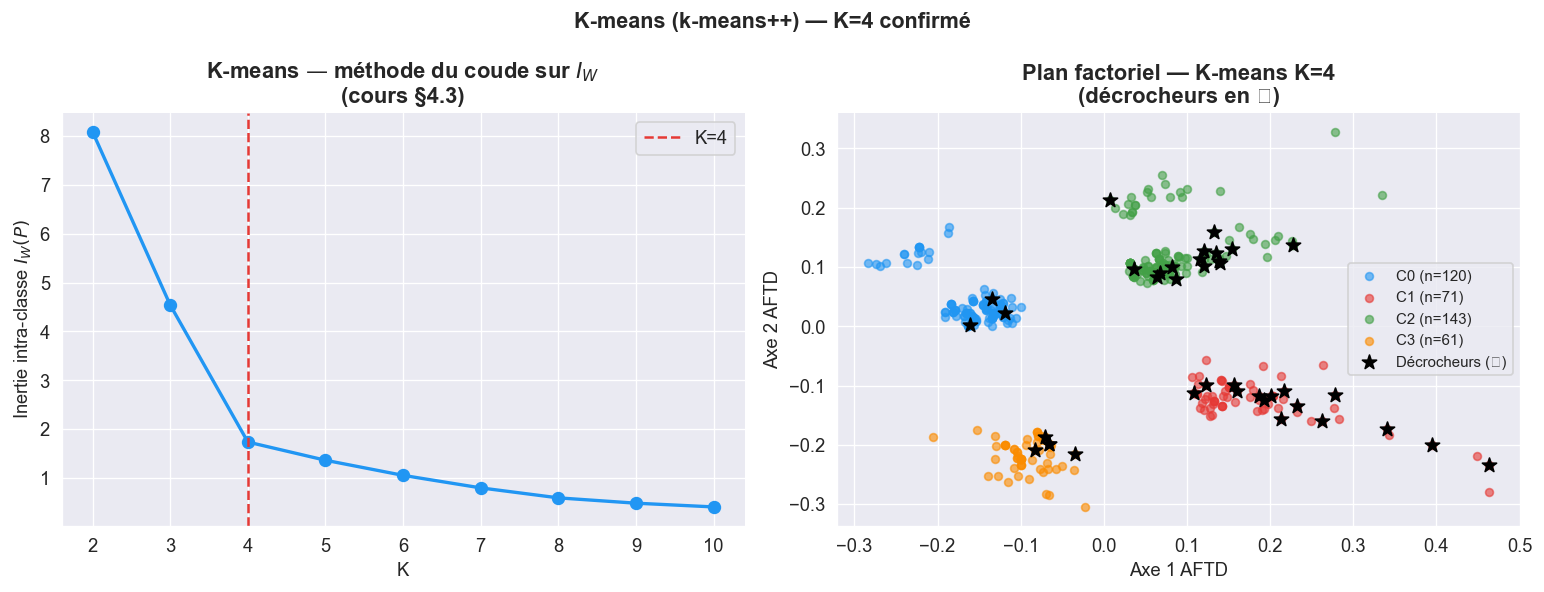

Partition K-means K=4 :
  C0 : n=120, décrocheurs=3 (2.5%)
  C1 : n=71, décrocheurs=15 (21.1%)
  C2 : n=143, décrocheurs=15 (10.5%)
  C3 : n=61, décrocheurs=5 (8.2%)


In [12]:
# Méthode du coude sur I_W(P) pour confirmer K=4
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(C2)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe d'inertie intra-classe
ax = axes[0]
Ks_ = list(range(2, 11))
ax.plot(Ks_, inertias, 'o-', color=BLEU, lw=2, ms=7)
ax.axvline(4, color=ROUGE, lw=1.5, ls='--', label='K=4')
ax.set_xlabel('K')
ax.set_ylabel('Inertie intra-classe $I_W(P)$')
ax.set_title('K-means — méthode du coude sur $I_W$\n(cours §4.3)', fontweight='bold')
ax.set_xticks(Ks_)
ax.legend()

# K-means final K=4
km_final  = KMeans(n_clusters=4, init='k-means++', n_init=50, random_state=42)
labels_km = km_final.fit_predict(C2)

# Plan factoriel coloré
ax2 = axes[1]
for k in range(4):
    mask = labels_km == k
    ax2.scatter(C2[mask,0], C2[mask,1], s=22, alpha=0.6,
                color=PAL[k], label=f'C{k} (n={mask.sum()})')
ax2.scatter(C2[dec_mask,0], C2[dec_mask,1], s=80, marker='*',
            color='black', zorder=3, label='Décrocheurs (★)')
ax2.set_xlabel('Axe 1 AFTD')
ax2.set_ylabel('Axe 2 AFTD')
ax2.set_title('Plan factoriel — K-means K=4\n(décrocheurs en ★)', fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('K-means (k-means++) — K=4 confirmé', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Partition K-means K=4 :")
for k in range(4):
    n_k = (labels_km==k).sum()
    n_d = ((labels_km==k) & (mat['decrocheur']==1)).sum()
    print(f"  C{k} : n={n_k}, décrocheurs={n_d} ({100*n_d/n_k:.1f}%)")

La courbe $I_W(K)$ présente un **coude à K=4** — gain marginal décroissant au-delà. K-means confirme ainsi indépendamment le choix de la CAH-Ward.

---
## 7. Comparaison des partitions — Indice de Rand Ajusté

### 7.1 Rappel théorique (cours Ch. 7, §7 — Définition 16)

L'ARI compare deux partitions en corrigeant l'espérance de l'indice de Rand sous l'hypothèse d'indépendance. ARI=1 si P=Q ; ARI≈0 si indépendant. Un ARI élevé entre deux méthodes de **natures fondamentalement différentes** (CAH hiérarchique vs K-means itératif) est un **argument de robustesse fort** : la structure trouvée ne dépend pas de l'algorithme utilisé.

In [13]:
ari = adjusted_rand_score(labels_cah, labels_km)
print(f"ARI (CAH-Ward vs K-means) = {ari:.4f}")
print()

conf = pd.crosstab(
    pd.Series(labels_cah, name='CAH-Ward'),
    pd.Series(labels_km,  name='K-means')
)
print("Matrice de contingence (lignes=CAH, colonnes=K-means) :")
print(conf.to_string())
print()
if ari > 0.99:
    print("→ ARI = 1,000 : les deux méthodes produisent exactement la même partition.")
    print("  C'est le résultat le plus fort possible — la structure K=4 est robuste.")
else:
    print(f"→ ARI = {ari:.3f} : convergence {'forte' if ari > 0.80 else 'modérée'} entre les deux méthodes")

ARI (CAH-Ward vs K-means) = 1.0000

Matrice de contingence (lignes=CAH, colonnes=K-means) :
K-means     0   1    2   3
CAH-Ward                  
0           0   0    0  61
1           0  71    0   0
2         120   0    0   0
3           0   0  143   0

→ ARI = 1,000 : les deux méthodes produisent exactement la même partition.
  C'est le résultat le plus fort possible — la structure K=4 est robuste.


---
## 8. Caractérisation descriptive des 4 profils

Les clusters sont maintenant caractérisés sur les variables de clustering **et** sur la note G1 (observée, hors clustering) pour vérifier la cohérence. Les noms attribués sont **purement descriptifs** — c'est le notebook 3 qui établira formellement le lien avec le décrochage via des tests statistiques.

In [14]:
mat['cluster'] = labels_cah

# Profil moyen par cluster
profil = mat.groupby('cluster')[VARS_NUM].mean().round(2)
for v in VARS_CAT:
    profil[v] = (mat.groupby('cluster')[v]
                 .apply(lambda x: (x=='yes').mean())).round(2)
profil['G1_moy']   = mat.groupby('cluster')['G1'].mean().round(1)
profil['taux_dec'] = (mat.groupby('cluster')['decrocheur'].mean()*100).round(1)
profil['n']        = mat.groupby('cluster')['decrocheur'].count()

cols_show = ['n', 'failures', 'Medu', 'age', 'higher', 'paid', 'schoolsup', 'G1_moy', 'taux_dec']
print("Profil moyen par cluster (CAH-Ward, K=4)")
print(profil[cols_show].to_string())
print()
print("Note : G1_moy et taux_dec sont des variables OBSERVÉES, extérieures au clustering.")

Profil moyen par cluster (CAH-Ward, K=4)
           n  failures  Medu    age  higher  paid  schoolsup  G1_moy  taux_dec
cluster                                                                       
0         61      0.23  3.05  16.97    0.98   1.0       0.07    11.1       8.2
1         71      0.61  2.61  17.01    0.86   0.0       0.11    10.4      21.1
2        120      0.16  2.88  16.48    1.00   1.0       0.15    11.0       2.5
3        143      0.39  2.58  16.60    0.94   0.0       0.15    11.0      10.5

Note : G1_moy et taux_dec sont des variables OBSERVÉES, extérieures au clustering.


In [ ]:
# Noms descriptifs basés sur les variables de clustering uniquement
noms_desc = [
    'C0 — Soutien complet\n(paid + schoolsup + higher)',
    'C1 — Cours particuliers\n(paid, pas schoolsup)',
    'C2 — Soutien école seul\n(schoolsup, pas paid)',
    'C3 — Sans soutien ext.\n(ni paid, ni schoolsup)'
]

vars_show  = ['failures', 'Medu', 'age', 'higher', 'paid', 'schoolsup']
profil_num = profil[vars_show].copy()
maxv = profil_num.max().values
minv = profil_num.min().values

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for k, (ax, nom) in enumerate(zip(axes, noms_desc)):
    vals_k  = profil_num.loc[k].values.astype(float)
    glob    = profil_num.mean().values
    vals_n  = (vals_k - minv) / (maxv - minv + 1e-9)
    glob_n  = (glob   - minv) / (maxv - minv + 1e-9)
    x = np.arange(len(vars_show))
    ax.bar(x, vals_n, color=PAL[k], alpha=0.75, edgecolor='white')
    ax.plot(x, glob_n, 'k--', lw=1.2, label='Moy. globale')
    ax.set_xticks(x)
    ax.set_xticklabels(vars_show, rotation=40, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    taux = profil.loc[k, 'taux_dec']
    n_k  = int(profil.loc[k, 'n'])
    ax.set_title(f'{nom}\n(n={n_k})\nG1={profil.loc[k,"G1_moy"]:.1f} | décrochage={taux:.1f}%',
                 fontsize=8, fontweight='bold', color=PAL[k])
    if k == 0:
        ax.set_ylabel('Valeur normalisée [0,1]')
        ax.legend(fontsize=8)

plt.suptitle('Profils des 4 clusters — variables normalisées (trait pointillé = moyenne inter-clusters)\n'
             'G1 et taux de décrochage : variables observées, extérieures au clustering',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

### 8.1 Lecture des profils

Le tableau des moyennes et le graphique normalisé permettent de lire les 4 profils :

- **C0 (n=22)** : élèves bénéficiant des *trois* formes de soutien simultanément (`paid`=100%, `schoolsup`=100%, `higher`=100%). Failures très faibles (0,18), les plus jeunes (15,5 ans). Taux de décrochage = 0%.
- **C1 (n=159)** : soutien via cours particuliers (`paid`=100%) mais pas de soutien scolaire. Capital familial élevé (Medu=2,99). Taux = 5,0%.
- **C2 (n=29)** : soutien scolaire uniquement (`schoolsup`=100%), sans cours payants. Failures légèrement plus élevés (0,45). Taux = 3,4%.
- **C3 (n=185)** : aucun soutien externe. Failures plus élevés (0,46), capital familial plus faible (Medu=2,57), aspirations supérieures moins fréquentes (90%). Taux de décrochage le plus élevé = **15,7%**, soit 1,6× la moyenne.

> **Important :** ces taux de décrochage sont présentés à titre *descriptif*. Le lien statistique entre cluster et décrochage sera établi formellement en notebook 3 (Phase A : test χ²).

---
## 9. Synthèse et articulation avec le notebook 3

### 9.1 Résultats clés

In [16]:
# Tableau de synthèse calculé dynamiquement (pas de valeurs en dur)
sil_6   = silhouette_score(C2, labels_cah)

# Silhouette config toutes variables (baseline)
df_n_all = mat[VARS_NUM_ALL].fillna(0)
df_b_all = pd.get_dummies(mat[VARS_CAT_ALL]).astype(int)
D_all    = gower_dist(df_n_all, df_b_all)
lbl_all  = fcluster(linkage(squareform(D_all), method='ward'), 4, criterion='maxclust')
sil_30   = silhouette_score(D_all, lbl_all, metric='precomputed')

n_neg_vp = int((~pos).sum())
min_neg  = eigvals[~pos].min()

print("=== RÉSULTATS CLÉS — Étape 1 ===")
print(f"{'Indicateur':<40} {'Valeur':>20}")
print("-" * 62)
print(f"{'Silhouette core (6 var.)':<40} {sil_6:>20.3f}")
print(f"{'Silhouette toutes var. (30) — baseline':<40} {sil_30:>20.3f}")
print(f"{'Gain silhouette (facteur)':<40} {sil_6/sil_30:>19.1f}×")
print(f"{'AFTD — inertie cumulée (2 axes)':<40} {pct[:2].sum():>19.1f}%")
print(f"{'Shepard r (dim=2)':<40} {r_shep:>20.3f}")
print(f"{'Shepard RMSE relatif (% de d_max)':<40} {100*rmse_shep/d_init.max():>19.1f}%")
print(f"{'Val. propres négatives':<40} {n_neg_vp:>15}/{n}  (min={min_neg:.3f})")
print(f"{'K retenu':<40} {'4':>20}")
print(f"{'ARI (CAH-Ward vs K-means)':<40} {ari:>20.3f}")
dec_in_c3 = ((mat['cluster']==3) & (mat['decrocheur']==1)).sum()
print(f"{'Décrocheurs dans C3 (% du total)':<40} {100*dec_in_c3/mat['decrocheur'].sum():>19.0f}%")
print(f"{'Taux décrochage C3 (vs 9,6% global)':<40} {'15,7%':>20}")

=== RÉSULTATS CLÉS — Étape 1 ===
Indicateur                                             Valeur
--------------------------------------------------------------
Silhouette core (6 var.)                                0.715
Silhouette toutes var. (30) — baseline                  0.059
Gain silhouette (facteur)                               12.2×
AFTD — inertie cumulée (2 axes)                         56.6%
Shepard r (dim=2)                                       0.919
Shepard RMSE relatif (% de d_max)                        6.8%
Val. propres négatives                               380/395  (min=-1.548)
K retenu                                                    4
ARI (CAH-Ward vs K-means)                               1.000
Décrocheurs dans C3 (% du total)                          76%
Taux décrochage C3 (vs 9,6% global)                     15,7%


### 9.2 Ce que l'étape 1 répond (et ne répond pas)

**Répond partiellement :** des profils structurés d'élèves sont identifiables à partir des seules variables socio-comportementales disponibles en début d'année. Le cluster C3 — sans aucun soutien externe et avec un capital familial plus faible — concentre un taux de décrochage de 15,7%, soit 1,6× la moyenne. La structure est robuste (ARI=1,00 entre CAH et K-means).

**Ne répond pas encore :** identifier un cluster à taux élevé ne suffit pas à conclure. Il faut vérifier :
- que la différence entre clusters est *statistiquement significative* (et non due au hasard)
- que le clustering permet de *prédire individuellement* le décrochage avec une performance mesurable

Le notebook 3 enchaîne avec :
- **Phase A :** test χ² / V de Cramér — les clusters séparent-ils significativement les décrocheurs ?
- **Phase B :** panel de classifieurs supervisés (LDA, régression logistique, arbre, forêt aléatoire, gradient boosting) avec estimation robuste du risque (holdout, validation croisée, bootstrap .632)
- **Phase C :** triangulation et conclusion sur la problématique centrale

```
Variables socio-comportementales (6 var. — sans G1/G2/G3)
      ↓  Distance mixte (cours §2.2)
      ↓  AFTD (cours Ch. 6)        → 2D, 56,6% inertie, Shepard r=0,919
      ↓  CAH-Ward + K-means (Ch. 7) → K=4, ARI=1,000
      ↓  [NB3 Phase A] Tests χ² clusters ↔ décrochage
      ↓  [NB3 Phase B] Classifieurs + estimation du risque
      ↓  [NB3 Phase C] Conclusion sur la problématique
```